## 5.1. Time Difference 기법 알고리즘

시간차를 이용한 정책 평가 (상태 가치 함수)

**입력:** 정책 π  
**출력:** 상태 가치 함수 V

**파라미터**

- α: 학습률 (learning rate)
- γ: 할인율 (discount factor)
- V(s): 상태 s의 가치 함수
- π: 평가할 정책
- r: 즉각적인 보상
- s': 다음 상태

**핵심 개념**

이 알고리즘은 **TD(0)** 방법을 사용하여 정책 π의 가치 함수를 평가
시간차 오차 δ = r + γV(s') - V(s)를 이용하여 가치 함수를 점진적으로 업데이트

**수도 코드**

- 모든 상태 s에 대해 V(s)를 0으로 초기화한다 (모든 상태 s와 모든 행동 a에 대해 q(s, a)를 0으로 초기화한다)
- while (수렴 조건을 만족하지 않음):
    - s를 초기 상태로 설정한다
    - while (s가 종료 상태가 아니면):
        - π에 따라 상태 s에서 행동 a를 선택한다 
            - Є-탐욕: [0,1] 사이의 uniform distribution의 난수 u를 생성
            - if u < Є: 랜덤 선택, else(u >= Є): π로 선택
            - Є-곱 스케줄링: max(Є_min, ЄxЄ_decay) - Q-Learning
            - Є-합 스케줄링: max(Є_min, Є-Є_decay) - Q-Learning
        - a를 실행하여 다음 상태 s'와 보상 r을 얻는다
        - V(s) ← V(s) + α(r + γV(s') - V(s))
        - s ← s'

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

---

### 5.2.1. Sarsa [On-policy] (State-Action-Reward-State-Action)

- 업데이트 규칙 | Q(s,a) + α(r + γQ(s',a') - Q(s,a))
- 다음 행동 | 실제 선택한 a' 사용

In [7]:
# State-Action-Reward-State-Action (SARSA) 알고리즘 
# 교재, 강의에서는 생략

---

### 5.2.2. Q-Learning [Off-policy] Q-Learning으로 FrozenLake 과업 학습

- 업데이트 규칙 | Q(s,a) + α(r + γmax Q(s',a) - Q(s,a))
- 다음 행동 | 최대값을 주는 행동 사용

In [2]:
# Q-Learning으로 FrozenLake 과업 학습 (1)

greedy_select = lambda x: np.random.choice(
    np.argwhere(x == np.max(x)).flatten()
)
# numpy 계열에서 최댓값을 가지는 원소의 인덱스(위치)를 1차원 배열로 반환

In [4]:
# Q-Learning으로 FrozenLake 과업 학습 (2)

def Q_Learning(env, 
               gamma: float,
               rho: float, 
               epsilon: float, 
               epsilon_decay: float, 
               epsilon_min: float, 
               num_episodes: int):
    
    Q = np.zeros(
        (env.observation_space.n, env.action_space.n)
    ) # 행동가치함수 Q-table 초기화 (td(0) : 상태공간 수 x 행동공간 수)
    
    Q_history = []  
    # Q 값의 학습 이력 추적 (에피소드 x 상태 x 행동)
    # 시각화 목적 (에피소드마다 Q값이 어떻게 변화하는지 관찰하기 위해)

    for i in range(num_episodes):
        # 에피소드 반복 [Monte-Carlo control과 유사]
        state, info = env.reset()
        # 에피소드 시작할 때 상태, 정보 초기화

        while True:
            # state가 종료 상태가 아닐 때까지 반복
            if np.random.uniform(0, 1) < epsilon:
                # Є-탐욕: [0,1] 사이의 uniform distribution의 난수 u를 생성
                action = np.random.randint(0, env.action_space.n)
                # if u < Є: 랜덤 선택
            else:
                action = greedy_select(Q[state, :])
                # else(u >= Є): π로 선택
            next_state, reward, terminated, truncated, info = env.step(action)
            # 행동 a를 취한 후 다음 상태 s', 보상 r, 종료 여부, 종료 조건, 정보 반환

            if terminated:
                # 종료 상태일 경우
                Q[state, action] = Q[state, action] + rho * (
                    reward - Q[state, action])
                # Q함수 업데이트
            else: 
                # 종료 상태가 아닐 경우
                Q[state, action] = Q[state, action] + rho * (
                    reward + gamma * np.max(Q[next_state, :]) - Q[state, action])
                # Q함수 업데이트

            state = next_state
            # 상태 다음으로 업데이트
            epsilon = max(epsilon * epsilon_decay, epsilon_min)
            # 곱 붕괴 Є 스케일링
            # epsilon = max(epsilon - epsilon_decay, epsilon_min)
            # 합 붕괴 Є 스케일링
            
            if terminated or truncated:
                # 종료 상태이거나 종료 조건이 만족될 경우
                break
                # 에피소드 종료
        
        Q_history.append(Q.copy())  # 각 에피소드 후 현재 Q를 기록
    
    pi = env.observation_space.n * [None]
    # 최적 정책 π 초기화 (상태공간 수 만큼 None으로 초기화)
    for state in range(env.observation_space.n):
        # 각 상태에 대한 최적 행동가치함수 Q에서 선택된 최댓값을 가지는 행동으로 최적 정책 구하기
        pi[state] = np.argmax(Q[state])
        # np.argmax() 함수는 배열에서 최댓값을 가지는 원소의 인덱스를 반환
    
    return pi, Q, Q_history
    # 최적 정책 π, 행동가치함수 Q, 그리고 Q의 학습 이력 반환

In [5]:
# Q-Learning으로 FrozenLake 과업 학습 (3)

env = gym.make("FrozenLake-v1", is_slippery = False, render_mode = "ansi")
# FrozenLake-v1 환경 생성

pi, Q, _ = Q_Learning(env, 
                   gamma = 0.99,
                   rho = 0.01, 
                   epsilon = 1.0,
                   epsilon_decay = 0.999,
                   epsilon_min = 0.05,
                   num_episodes = 10000)
# Q-Learning으로 최적 정책 π와 행동가치함수 Q 구하기
# reward - 0: Left, 1: Down, 2: Right, 3: Up

print("최적정책 π: \n", np.array(pi).reshape(4, 4),
      "\n행동가치함수 Q: \n", np.round(Q, 3))
env.close()

최적정책 π: 
 [[1 0 0 0]
 [1 0 1 0]
 [2 2 1 0]
 [0 2 2 0]] 
행동가치함수 Q: 
 [[0.683 0.951 0.359 0.62 ]
 [0.695 0.    0.    0.   ]
 [0.011 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.597 0.961 0.    0.557]
 [0.    0.    0.    0.   ]
 [0.    0.643 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.619 0.    0.97  0.609]
 [0.698 0.504 0.98  0.   ]
 [0.718 0.99  0.    0.286]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.021 0.907 0.029]
 [0.495 0.696 1.    0.771]
 [0.    0.    0.    0.   ]]


In [54]:
# Q-Learning으로 FrozenLake 과업 학습 (4)

num_runs: int = 5
policies = [] # 최적 정책을 저장할 리스트 초기화
paths = [] # 최적 정책에 따라 행동을 선택하여 경로를 저장할 리스트 초기화

for run in range(num_runs):
    # Q-Learning으로 FrozenLake 과업 학습 num_runs만큼 반복
    pi, Q, _ = Q_Learning(env, 
                   gamma = 0.99,
                   rho = 0.01, 
                   epsilon = 1.0,
                   epsilon_decay = 0.999,
                   epsilon_min = 0.05,
                   num_episodes = 10000)
    # Q-Learning으로 최적 정책 π와 행동가치함수 Q 구하기
    
    policies.append(pi)
    # 최적 정책 π를 policies 리스트에 추가

    path = [] # 경로 추출
    state = 0 # 상태 초기화
    action_map = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}
    action_visual = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    visited_states = [0]  # 방문한 상태 기록할 리스트 초기화

    while state != 15:
    # 종료상태에 도달할 때까지 반복
        action = pi[state]
        # 행동 선택
        path.append(action_map[action])
        # 행동을 경로에 추가

        # 다음 상태를 계산 (4 x 4 그리드)
        if action == 0:  # Left
            next_state = state - 1 if state % 4 != 0 else state
            # 왼쪽으로 이동할 때, 현재 상태가 왼쪽 가장자리가 아니면 다음 상태는 '현재 상태 - 1', 그렇지 않으면 현재 상태 유지
        elif action == 1:  # Down
            next_state = state + 4 if state < 12 else state
            # 아래로 이동할 때, 현재 상태가 아래쪽 가장자리가 아니면 다음 상태는 '현재 상태 + 4', 그렇지 않으면 현재 상태 유지
        elif action == 2:  # Right
            next_state = state + 1 if state % 4 != 3 else state
            # 오른쪽으로 이동할 때, 현재 상태가 오른쪽 가장자리가 아니면 다음 상태는 '현재 상태 + 1', 그렇지 않으면 현재 상태 유지    
        elif action == 3:  # Up
            next_state = state - 4 if state >= 4 else state
            # 위로 이동할 때, 현재 상태가 위쪽 가장자리가 아니면 다음 상태는 '현재 상태 - 4', 그렇지 않으면 현재 상태 유지
        
        state = next_state
        # 상태 업데이트
        visited_states.append(state)
        # 방문 상태 기록
        if len(visited_states) > 50:
            # 방문 상태가 50개를 초과할 경우
            break
            # 경로 탐색 종료

        # 실행 결과 출력
        print(f"\n[실행 {run + 1}]")
        print(f"경로: {' → '.join(path)}")
        print(f"방문 상태: {' → '.join(map(str, visited_states))}")


[실행 1]
경로: Right
방문 상태: 0 → 1

[실행 1]
경로: Right → Right
방문 상태: 0 → 1 → 2

[실행 1]
경로: Right → Right → Down
방문 상태: 0 → 1 → 2 → 6

[실행 1]
경로: Right → Right → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10

[실행 1]
경로: Right → Right → Down → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10 → 14

[실행 1]
경로: Right → Right → Down → Down → Down → Right
방문 상태: 0 → 1 → 2 → 6 → 10 → 14 → 15

[실행 2]
경로: Right
방문 상태: 0 → 1

[실행 2]
경로: Right → Right
방문 상태: 0 → 1 → 2

[실행 2]
경로: Right → Right → Down
방문 상태: 0 → 1 → 2 → 6

[실행 2]
경로: Right → Right → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10

[실행 2]
경로: Right → Right → Down → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10 → 14

[실행 2]
경로: Right → Right → Down → Down → Down → Right
방문 상태: 0 → 1 → 2 → 6 → 10 → 14 → 15

[실행 3]
경로: Right
방문 상태: 0 → 1

[실행 3]
경로: Right → Right
방문 상태: 0 → 1 → 2

[실행 3]
경로: Right → Right → Down
방문 상태: 0 → 1 → 2 → 6

[실행 3]
경로: Right → Right → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10

[실행 3]
경로: Right → Right → Down → Down → Down
방문 상태: 0 → 1 → 2 → 6 → 10 → 14

[

- 프로그램 실행 결괴를 살펴보면, 상태 0 에서 시작하여 R → R → D → D → D → R 을거쳐 보상 1 을받는 상태 15에 도달하는 경로를 찾았다. 
- 이 프로그램은 난수를 시용하기 때문에 여러 번 실행하다 보면 또 다른 최적 정책 [1, 0, 0, 0, 1, 0, 0, 0, 2, 2, 1, 0, 0, 0, 2, 0], 즉 D → D → R → R → D → R 경로를 찾는다.

> [실행 1]
> 경로: Right → Right → Down → Down → Down → Right
> 방문 상태: 0 → 1 → 2 → 6 → 10 → 14 → 15

> [실행 2]
> 경로: Down → Down → Right → Down → Right → Right
> 방문 상태: 0 → 4 → 8 → 9 → 13 → 14 → 15

> [실행 3]
> 경로: Down → Down → Right → Down → Right → Right
> 방문 상태: 0 → 4 → 8 → 9 → 13 → 14 → 15

> [실행 4]
> 경로: Down → Down → Right → Right → Down → Right
> 방문 상태: 0 → 4 → 8 → 9 → 10 → 14 → 15

> [실행 5]
> 경로: Down → Down → Right → Down → Right → Right
> 방문 상태: 0 → 4 → 8 → 9 → 13 → 14 → 15

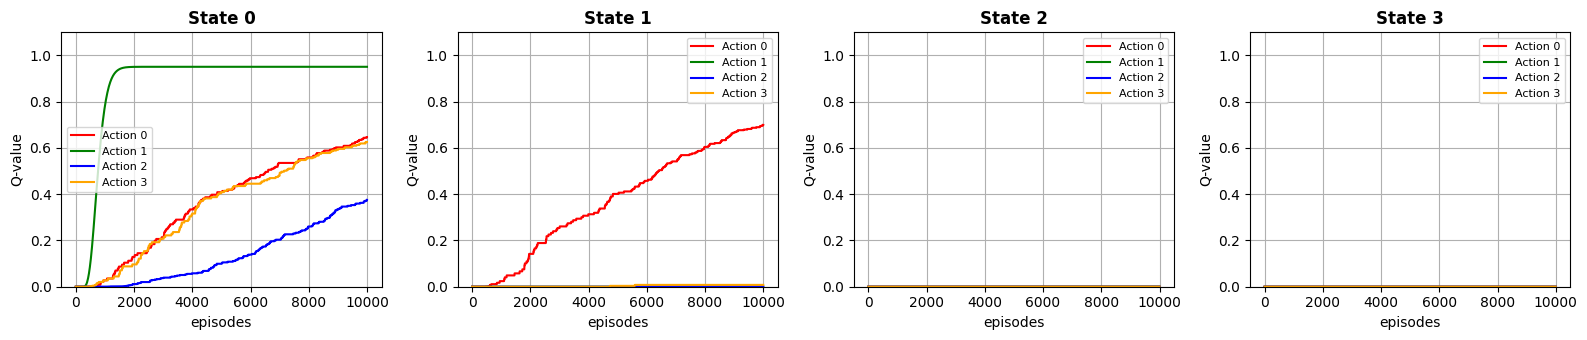

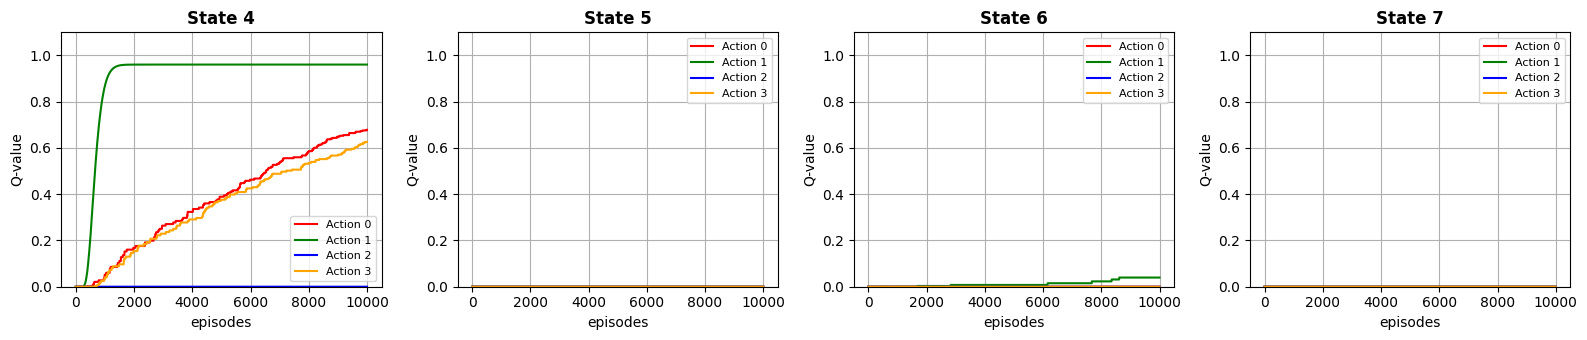

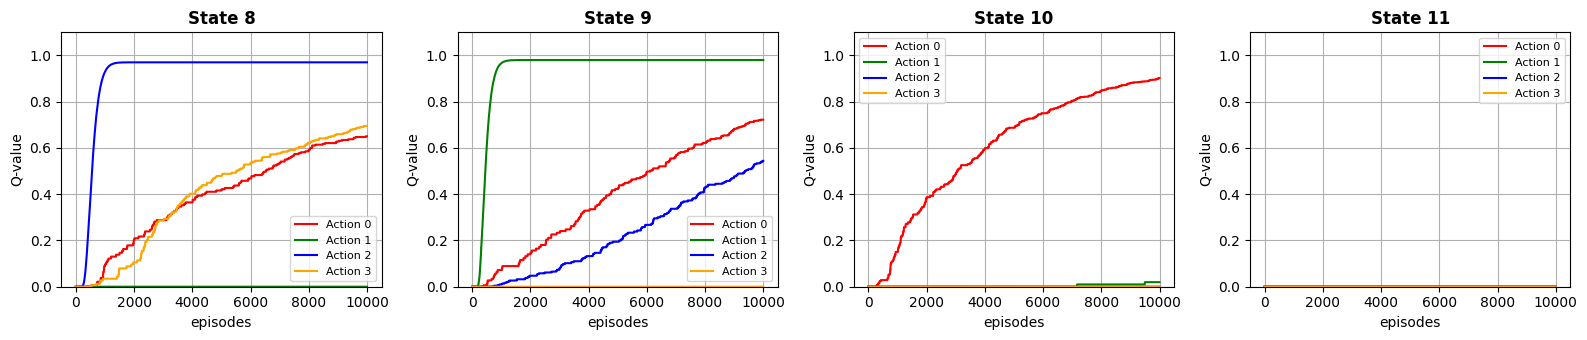

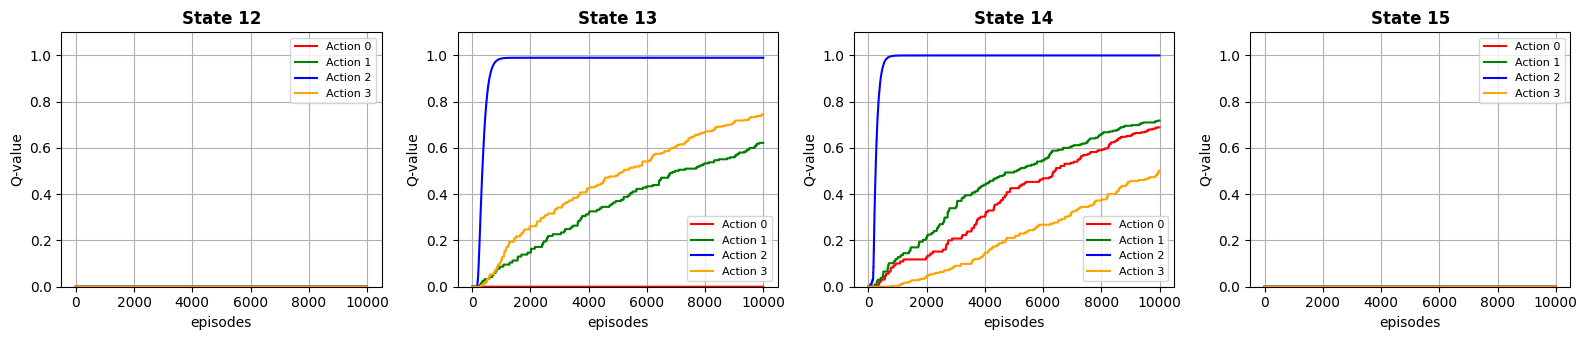

In [ ]:
def learning_curve(Qs, state, ax):
    """ Q-learning의 학습 곡선
    Args:
    - Qs: 행동가치함수 Q의 학습 과정 (에피소드 수 x 상태 수 x 행동 수)
    - state: 상태
    - ax: matplotlib axis 객체
    """

    colors = ["red", "green", "blue", "orange"]
    for action in range(env.action_space.n):
        ax.plot(
            np.array(Qs)[:, state, action],
            color=colors[action],
            label=f"Action {action}")
    ax.set_title(f"State {state}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Q-value")
    ax.set_xlabel("episodes")
    ax.set_ylim(0, 1.1)
    ax.grid()
    ax.legend(fontsize = 8)

pi, Q, Q_history = Q_Learning(env, 
                   gamma = 0.99,
                   rho = 0.01,  
                   epsilon = 1.0,
                   epsilon_decay = 0.999,
                   epsilon_min = 0.05,
                   num_episodes = 10000)
# Q-Learning으로 최적 정책 π와 행동가치함수 Q 구하기
env.close()

# 4개씩 한 행에 배치하여 학습 곡선 그리기
for i in range(0, env.observation_space.n, 4):
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
    for j in range(4):
        state = i + j
        if state < env.observation_space.n:
            learning_curve(Qs = Q_history, state = state, ax = axes[j])
    plt.tight_layout()
    plt.show()

---

### 5.2.2. Q-Learning [Off-policy] Q-Learning으로 Black Jack Game 학습

- 업데이트 규칙 | Q(s,a) + α(r + γmax Q(s',a) - Q(s,a))
- 다음 행동 | 최대값을 주는 행동 사용
- 출처 : https://github.com/dennybritz/reinforcement-learning/tree/master/TD